# 🧠 PRÁCTICA OBLIGATORIA: K-Means Clustering
### Dataset de caras Olivetti

## Ejercicio 0 – Importar librerías
Primero de todo importamos todo lo que vamos a necesitar a lo largo del notebook.

In [1]:
# Librerías básicas de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Para cargar el dataset de caras
from sklearn.datasets import fetch_olivetti_faces

# Para dividir los datos en train/validación/test
from sklearn.model_selection import train_test_split

# Para reducir dimensionalidad (PCA)
from sklearn.decomposition import PCA

# Para el clustering K-Means
from sklearn.cluster import KMeans

# Para medir la calidad del clustering
from sklearn.metrics import silhouette_score

# Para el clasificador Random Forest
from sklearn.ensemble import RandomForestClassifier

print('✅ Todo importado correctamente')

✅ Todo importado correctamente


## #1.1 – Cargar el dataset Olivetti

In [2]:
# Cargamos el dataset
olivetti = fetch_olivetti_faces()

# Mostramos la descripción
print(olivetti['DESCR'])

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to C:\Users\hugot\scikit_learn_data
.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for s

## #1.2 – Ver el target y crear el DataFrame
El target nos dice qué persona sale en cada foto (0-39). Lo añadimos al DataFrame y barajamos.

In [3]:
# El target nos dice qué persona es cada imagen (número del 0 al 39)
print('Target (primeros 20):', olivetti.target[:20])

# Creamos un DataFrame con todos los píxeles de cada imagen
df = pd.DataFrame(olivetti.data)

# Añadimos la columna target
df['target'] = olivetti.target

print(f'\nDataFrame creado: {df.shape[0]} filas, {df.shape[1]} columnas')
print(f'(Las primeras 4096 columnas son píxeles, la última es la persona)')

# Barajamos aleatoriamente todas las filas
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nDataFrame barajado. Primeras targets: {df["target"].values[:10]}')

Target (primeros 20): [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]

DataFrame creado: 400 filas, 4097 columnas
(Las primeras 4096 columnas son píxeles, la última es la persona)

DataFrame barajado. Primeras targets: [20 28  3 21  9  8 32  9 26 12]


## #1.3 – División en Train / Validación / Test (80-10-10)
Dividimos en tres partes. Usamos **muestreo estratificado** para que cada conjunto tenga fotos de todas las personas.

Como scikit-learn no permite dividir en 3 de golpe, hacemos dos divisiones:
1. Primero separamos el 10% para test → nos queda el 90%
2. Luego del 90%, separamos un 11.1% para validación → eso es ~10% del total

In [4]:
# Separamos features (X) y etiquetas (y)
X = df.drop('target', axis=1)   # todos los píxeles
y = df['target']                  # la persona que es

# PASO 1: Separamos test (10%) del resto (90%)
# stratify=y asegura que haya el mismo número de fotos de cada persona
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.10,     # 10% para test
    stratify=y,         # que haya de todas las personas
    random_state=42
)

# PASO 2: Del 90% que queda, separamos validación (~11.1% del 90% = ~10% del total)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val, y_train_val,
    test_size=0.111,
    stratify=y_train_val,
    random_state=42
)

print(f'Train:      {X_train.shape[0]} imágenes ({X_train.shape[0]/400*100:.0f}%)')
print(f'Validación: {X_valid.shape[0]} imágenes ({X_valid.shape[0]/400*100:.0f}%)')
print(f'Test:       {X_test.shape[0]} imágenes ({X_test.shape[0]/400*100:.0f}%)')

Train:      320 imágenes (80%)
Validación: 40 imágenes (10%)
Test:       40 imágenes (10%)


## #1.4 – Visualizar algunas caras
Usamos la función proporcionada para ver cómo son las imágenes.

Primeras 10 caras del conjunto de entrenamiento:


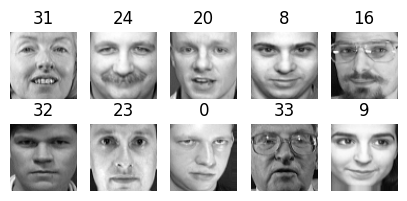

In [5]:
# Función para visualizar caras
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)  # convertir de 4096 píxeles a imagen 64x64
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap='gray')
        plt.axis('off')
        plt.title(label)
    plt.show()

# Mostramos las primeras 10 caras del conjunto de entrenamiento
print('Primeras 10 caras del conjunto de entrenamiento:')
plot_faces(
    X_train.iloc[:10].values,   # usamos iloc para seleccionar por posición
    y_train.iloc[:10].values    # igual con las etiquetas
)

## #1.5 – Reducción de dimensionalidad con PCA
Cada imagen tiene 4096 features (píxeles). Eso es demasiado para trabajar cómodamente.
**PCA** nos permite resumir esa información en muchas menos columnas, conservando el 99% de la información.

In [6]:
# PCA con 0.99 = conserva el 99% de la varianza (información) de los datos
pca = PCA(0.99, random_state=42)

# fit_transform: aprende cómo reducir Y lo aplica al train
X_train_pca = pca.fit_transform(X_train)

# transform: solo aplica lo aprendido (sin volver a aprender)
X_valid_pca = pca.transform(X_valid)
X_test_pca  = pca.transform(X_test)

print(f'Dimensiones originales:  {X_train.shape[1]} features (píxeles)')
print(f'Dimensiones tras PCA:    {pca.n_components_} componentes')
print(f'¡Hemos reducido de {X_train.shape[1]} a {pca.n_components_} columnas conservando el 99% de la info!')

Dimensiones originales:  4096 features (píxeles)
Dimensiones tras PCA:    221 componentes
¡Hemos reducido de 4096 a 221 columnas conservando el 99% de la info!


## #1.6 – Encontrar el mejor K con el Score de Silueta
El **score de silueta** mide qué tan bien separados están los clústeres. Cuanto más alto (cerca de 1), mejor.

Vamos a probar valores de K de 5 en 5 hasta 150 y nos quedamos con el que dé mejor score.

Probando diferentes valores de K...
(Esto puede tardar unos minutos, ¡ten paciencia!)
  k=  5  →  silueta = 0.1005
  k= 10  →  silueta = 0.0993
  k= 15  →  silueta = 0.0988
  k= 20  →  silueta = 0.1050
  k= 25  →  silueta = 0.1198
  k= 30  →  silueta = 0.1191
  k= 35  →  silueta = 0.1529
  k= 40  →  silueta = 0.1497
  k= 45  →  silueta = 0.1475
  k= 50  →  silueta = 0.1603
  k= 55  →  silueta = 0.1707
  k= 60  →  silueta = 0.1664
  k= 65  →  silueta = 0.1707
  k= 70  →  silueta = 0.1779
  k= 75  →  silueta = 0.1661
  k= 80  →  silueta = 0.1753
  k= 85  →  silueta = 0.1736
  k= 90  →  silueta = 0.1878
  k= 95  →  silueta = 0.1749
  k=100  →  silueta = 0.1742
  k=105  →  silueta = 0.1685
  k=110  →  silueta = 0.1789
  k=115  →  silueta = 0.1705
  k=120  →  silueta = 0.1670
  k=125  →  silueta = 0.1693
  k=130  →  silueta = 0.1656
  k=135  →  silueta = 0.1823
  k=140  →  silueta = 0.1634
  k=145  →  silueta = 0.1637
  k=150  →  silueta = 0.1543

🏆 Mejor K según silueta: k=90 (score=0.1878

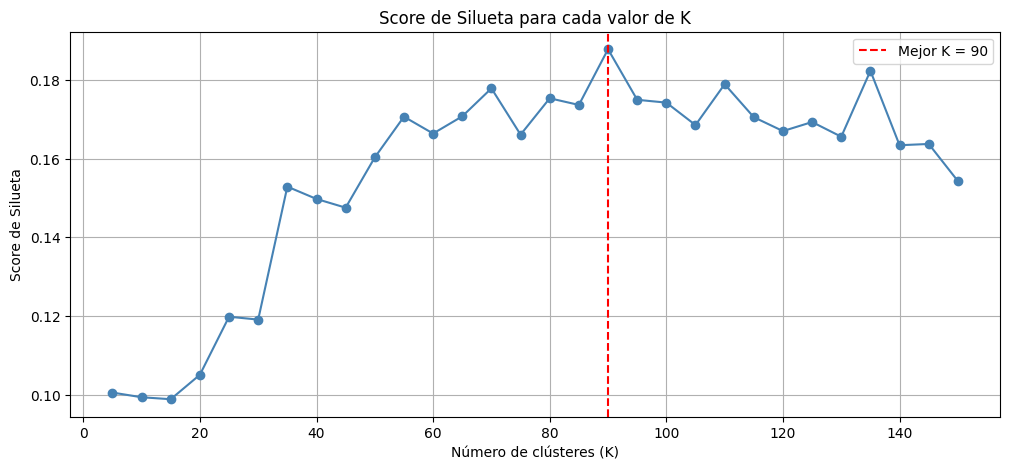

In [7]:
# Vamos a guardar los scores para cada valor de K
silhouette_scores = []
k_values = list(range(5, 151, 5))  # [5, 10, 15, ..., 150]

print('Probando diferentes valores de K...')
print('(Esto puede tardar unos minutos, ¡ten paciencia!)')

for k in k_values:
    # Creamos el modelo K-Means con k clústeres
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Entrenamos y obtenemos las etiquetas de clúster de cada imagen
    labels = km.fit_predict(X_train_pca)
    
    # Calculamos el score de silueta
    # sample_size=200 hace el cálculo más rápido usando solo 200 muestras
    score = silhouette_score(X_train_pca, labels, sample_size=200, random_state=42)
    silhouette_scores.append(score)
    
    print(f'  k={k:3d}  →  silueta = {score:.4f}')

# ¿Cuál fue el mejor?
best_k_sil = k_values[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print(f'\n🏆 Mejor K según silueta: k={best_k_sil} (score={best_score:.4f})')

# Dibujamos la gráfica
plt.figure(figsize=(12, 5))
plt.plot(k_values, silhouette_scores, marker='o', color='steelblue')
plt.axvline(x=best_k_sil, color='red', linestyle='--', label=f'Mejor K = {best_k_sil}')
plt.xlabel('Número de clústeres (K)')
plt.ylabel('Score de Silueta')
plt.title('Score de Silueta para cada valor de K')
plt.legend()
plt.grid(True)
plt.show()

## #1.7 – Método del Codo (Inercia)
La **inercia** mide qué tan compactos son los clústeres (la suma de distancias al centro).
Queremos que baje, pero sin pasarnos de clústeres. El 'codo' es donde deja de bajar tan rápido.

Calculando inercias...


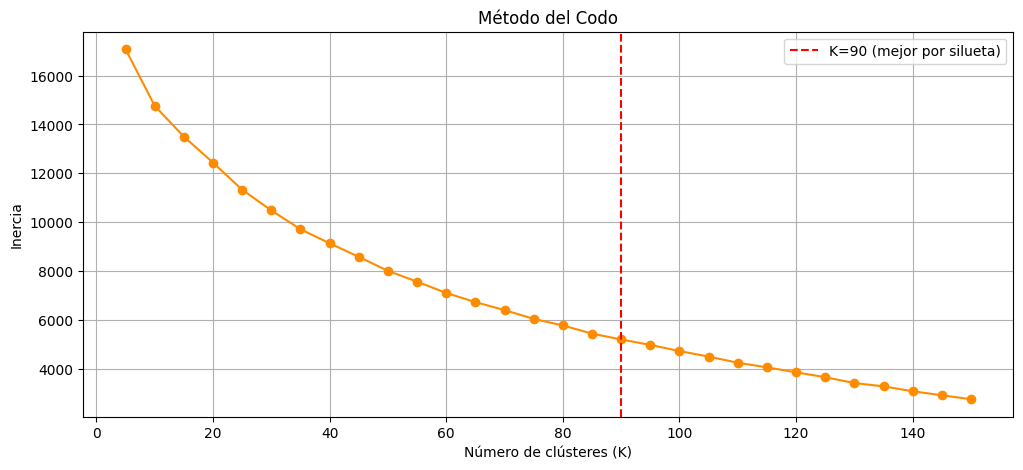

📌 Observación: Busca dónde la curva empieza a "doblarse" como un codo.
   La silueta sugirió k=90, que tiene mucho sentido porque hay 40 personas en el dataset.


In [8]:
# Guardamos la inercia para cada K
inertias = []

print('Calculando inercias...')

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_pca)
    inertias.append(km.inertia_)

# Dibujamos la gráfica del codo
plt.figure(figsize=(12, 5))
plt.plot(k_values, inertias, marker='o', color='darkorange')
plt.axvline(x=best_k_sil, color='red', linestyle='--', label=f'K={best_k_sil} (mejor por silueta)')
plt.xlabel('Número de clústeres (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.legend()
plt.grid(True)
plt.show()

print('📌 Observación: Busca dónde la curva empieza a "doblarse" como un codo.')
print(f'   La silueta sugirió k={best_k_sil}, que tiene mucho sentido porque hay 40 personas en el dataset.')

## #1.8 – Entrenar el modelo final con el mejor K
Usamos el K que encontramos con el score de silueta.

In [9]:
# Entrenamos el modelo definitivo con el mejor K
best_model = KMeans(n_clusters=best_k_sil, random_state=42, n_init=10)
best_model.fit(X_train_pca)

print(f'✅ Modelo entrenado con K={best_k_sil} clústeres')
print(f'   Inercia final: {best_model.inertia_:.2f}')

✅ Modelo entrenado con K=90 clústeres
   Inercia final: 5212.12


## #1.9 – ¿El modelo agrupa caras similares?
Vamos a ver qué caras asignó a los primeros 10 clústeres.


--- Clúster 0 (3 imágenes) ---


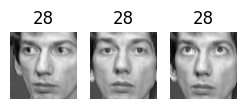


--- Clúster 1 (7 imágenes) ---


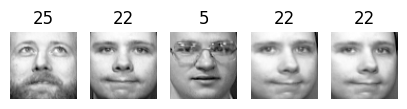


--- Clúster 2 (5 imágenes) ---


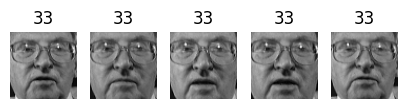


--- Clúster 3 (3 imágenes) ---


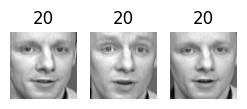


--- Clúster 4 (2 imágenes) ---


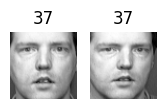


--- Clúster 5 (4 imágenes) ---


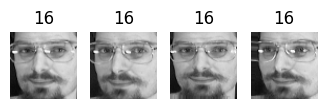


--- Clúster 6 (3 imágenes) ---


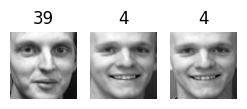


--- Clúster 7 (5 imágenes) ---


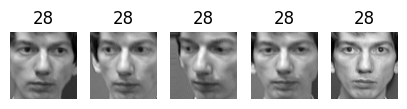


--- Clúster 8 (5 imágenes) ---


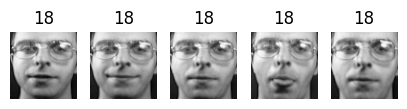


--- Clúster 9 (1 imágenes) ---


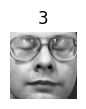


📌 Conclusión: Si ves que los números en los títulos se repiten dentro de cada clúster,
   ¡significa que el modelo agrupó bien las caras de la misma persona!


In [10]:
# Obtenemos la etiqueta de clúster que asignó el modelo a cada imagen
cluster_labels = best_model.labels_

# Necesitamos X_train en formato numpy (array) para poder usar reshape
X_train_array = X_train.values
y_train_array = y_train.values

# Vemos las caras de los 10 primeros clústeres
for cluster_id in range(10):
    # Encontramos qué imágenes pertenecen a este clúster
    indices = np.where(cluster_labels == cluster_id)[0]
    
    # Tomamos máximo 5 caras por clúster
    indices = indices[:5]
    
    print(f'\n--- Clúster {cluster_id} ({len(np.where(cluster_labels == cluster_id)[0])} imágenes) ---')
    
    # ¡Ojo! Aquí usamos las imágenes ORIGINALES (X_train_array), no las de PCA
    plot_faces(
        X_train_array[indices],
        y_train_array[indices]
    )

print('\n📌 Conclusión: Si ves que los números en los títulos se repiten dentro de cada clúster,')
print('   ¡significa que el modelo agrupó bien las caras de la misma persona!')

---
## #2.1 – Clasificador Random Forest (sin clustering)
Ahora entrenamos un clasificador para predecir qué persona es cada imagen.
Usamos Random Forest con 150 árboles.

In [11]:
# Creamos el clasificador con 150 estimadores (árboles de decisión)
rf_sin_clustering = RandomForestClassifier(n_estimators=150, random_state=42)

# Entrenamos con las imágenes reducidas por PCA
rf_sin_clustering.fit(X_train_pca, y_train)

# Evaluamos en el conjunto de validación
accuracy_sin = rf_sin_clustering.score(X_valid_pca, y_valid)

print(f'✅ Random Forest entrenado')
print(f'   Accuracy en validación: {accuracy_sin:.4f} ({accuracy_sin*100:.1f}%)')
print(f'   (Esto significa que acierta en el {accuracy_sin*100:.1f}% de los casos)')

✅ Random Forest entrenado
   Accuracy en validación: 0.9750 (97.5%)
   (Esto significa que acierta en el 97.5% de los casos)


## #2.2 – K-Means como reducción de dimensionalidad
Una idea interesante: en lugar de usar las features directamente, usamos las **distancias al centroide** de cada clúster como features.

Esto convierte el clustering en una herramienta de transformación de datos.

In [12]:
# transform() nos da la distancia de cada imagen a cada centroide
# Si tenemos K clústeres, obtenemos K distancias por imagen
X_train_reduced = best_model.transform(X_train_pca)
X_valid_reduced  = best_model.transform(X_valid_pca)
X_test_reduced   = best_model.transform(X_test_pca)

print(f'Dimensiones antes: {X_train_pca.shape[1]} features')
print(f'Dimensiones ahora: {X_train_reduced.shape[1]} features (= K distancias)')

# Entrenamos un nuevo Random Forest con estas nuevas features
rf_con_clustering = RandomForestClassifier(n_estimators=150, random_state=42)
rf_con_clustering.fit(X_train_reduced, y_train)

accuracy_con = rf_con_clustering.score(X_valid_reduced, y_valid)

print(f'\n--- Comparación ---')
print(f'Accuracy SIN clustering: {accuracy_sin:.4f} ({accuracy_sin*100:.1f}%)')
print(f'Accuracy CON clustering: {accuracy_con:.4f} ({accuracy_con*100:.1f}%)')

if accuracy_con >= accuracy_sin:
    print('\n✅ El clustering mejoró o mantuvo el rendimiento del clasificador')
else:
    print('\n📌 En este caso el clustering no mejoró el accuracy, pero es una técnica muy útil')
    print('   en problemas reales con más datos y más ruido.')

Dimensiones antes: 221 features
Dimensiones ahora: 90 features (= K distancias)

--- Comparación ---
Accuracy SIN clustering: 0.9750 (97.5%)
Accuracy CON clustering: 0.9250 (92.5%)

📌 En este caso el clustering no mejoró el accuracy, pero es una técnica muy útil
   en problemas reales con más datos y más ruido.
